# Hospital Readmission Prediction

## Project Goal

The goal of this notebook is to predict whether a patient will be **readmitted to the hospital within 30 days** of discharge, using patient information such as vital signs, prior healthcare visits, and diagnosis-related details.


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report,
    roc_auc_score,
    roc_curve
)


In [2]:
df = pd.read_csv("hospital_readmission.csv")
df.head()

,age,gender,heart_rate,systolic_bp,diastolic_bp,temperature,oxygen_saturation,num_prior_visits,num_emergency_visits,num_inpatient_visits,num_diagnoses,length_of_stay,diabetes,hypertension,previous_readmission,readmitted_30_days
0,69,Male,68.0,101.0,73.0,98.7,96.2,0,1,1,1,13,0,0,1,1
1,32,Male,86.0,120.0,81.0,98.6,96.6,3,1,0,8,4,1,1,1,1
2,89,Male,76.0,139.0,95.0,97.9,92.3,4,0,2,9,7,0,1,0,1
3,78,Male,73.0,150.0,80.0,99.7,100.4,5,3,2,3,5,1,0,0,0
4,38,Female,68.0,120.0,67.0,97.8,97.2,3,0,2,7,1,0,0,0,1


In [3]:
df.shape

(10000, 16)

In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 16 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   age                   10000 non-null  int64  
 1   gender                10000 non-null  str    
 2   heart_rate            10000 non-null  float64
 3   systolic_bp           10000 non-null  float64
 4   diastolic_bp          10000 non-null  float64
 5   temperature           10000 non-null  float64
 6   oxygen_saturation     10000 non-null  float64
 7   num_prior_visits      10000 non-null  int64  
 8   num_emergency_visits  10000 non-null  int64  
 9   num_inpatient_visits  10000 non-null  int64  
 10  num_diagnoses         10000 non-null  int64  
 11  length_of_stay        10000 non-null  int64  
 12  diabetes              10000 non-null  int64  
 13  hypertension          10000 non-null  int64  
 14  previous_readmission  10000 non-null  int64  
 15  readmitted_30_days    10000 non

In [5]:
df.isnull().sum()

age                     0
gender                  0
heart_rate              0
systolic_bp             0
diastolic_bp            0
temperature             0
oxygen_saturation       0
num_prior_visits        0
num_emergency_visits    0
num_inpatient_visits    0
num_diagnoses           0
length_of_stay          0
diabetes                0
hypertension            0
previous_readmission    0
readmitted_30_days      0
dtype: int64

In [6]:
df.duplicated().sum()

np.int64(0)

In [8]:
df.describe()

,age,heart_rate,systolic_bp,diastolic_bp,temperature,oxygen_saturation,num_prior_visits,num_emergency_visits,num_inpatient_visits,num_diagnoses,length_of_stay,diabetes,hypertension,previous_readmission,readmitted_30_days
count,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.00000,10000.00000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000
mean,54.018800,78.139500,124.892900,79.921000,98.203170,97.005610,1.988500,0.99440,1.02380,4.977600,7.545200,0.299800,0.402100,0.252600,0.471600
std,21.051422,12.061848,17.825757,10.022964,0.801406,2.022893,1.406544,1.00313,1.01328,2.560577,4.039949,0.458193,0.490346,0.434525,0.499218
min,18.000000,32.000000,59.000000,35.000000,94.800000,88.700000,0.000000,0.00000,0.00000,1.000000,1.000000,0.000000,0.000000,0.000000,0.000000
25%,36.000000,70.000000,113.000000,73.000000,97.700000,95.600000,1.000000,0.00000,0.00000,3.000000,4.000000,0.000000,0.000000,0.000000,0.000000
50%,54.000000,78.000000,125.000000,80.000000,98.200000,97.000000,2.000000,1.00000,1.00000,5.000000,8.000000,0.000000,0.000000,0.000000,0.000000
75%,72.000000,86.000000,137.000000,87.000000,98.700000,98.400000,3.000000,2.00000,2.00000,7.000000,11.000000,1.000000,1.000000,1.000000,1.000000
max,90.000000,132.000000,191.000000,117.000000,101.000000,104.500000,12.000000,7.00000,7.00000,9.000000,14.000000,1.000000,1.000000,1.000000,1.000000


In [9]:
df["readmitted_30_days"].value_counts()

readmitted_30_days
0    5284
1    4716
Name: count, dtype: int64

In [11]:
import seaborn as sns

In [13]:
df["readmitted_30_days"].value_counts(normalize=True)*100

readmitted_30_days
0    52.84
1    47.16
Name: proportion, dtype: float64

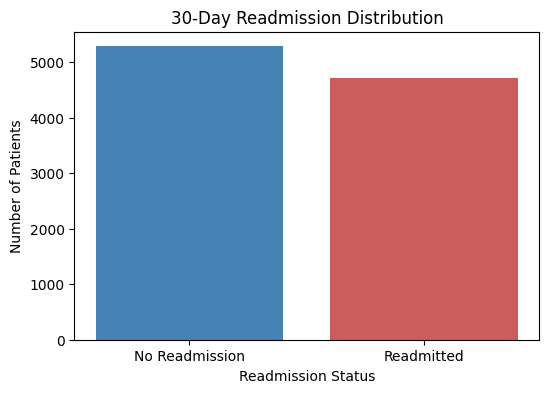

In [14]:
counts = df["readmitted_30_days"].value_counts().sort_index()
labels = ["No Readmission", "Readmitted"]

plt.figure(figsize=(6, 4))
plt.bar(labels, counts.values, color=["steelblue", "indianred"])
plt.title("30-Day Readmission Distribution")
plt.xlabel("Readmission Status")
plt.ylabel("Number of Patients")
plt.show()


## 5. Exploratory Data Analysis (EDA)

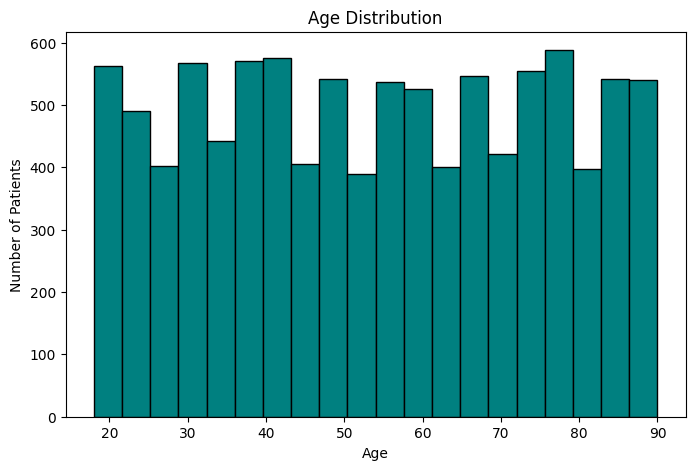

In [15]:
#  Age Distribution
plt.figure(figsize=(8, 5))
plt.hist(df["age"], bins=20, color="teal", edgecolor="black")
plt.title("Age Distribution")
plt.xlabel("Age")
plt.ylabel("Number of Patients")
plt.show()


In [16]:
# Compare average 30-day readmission rate for patients with vs. without a previous readmission
readmit_rate_by_prev = df.groupby("previous_readmission")["readmitted_30_days"].mean()
readmit_rate_by_prev


previous_readmission
0    0.413299
1    0.644101
Name: readmitted_30_days, dtype: float64

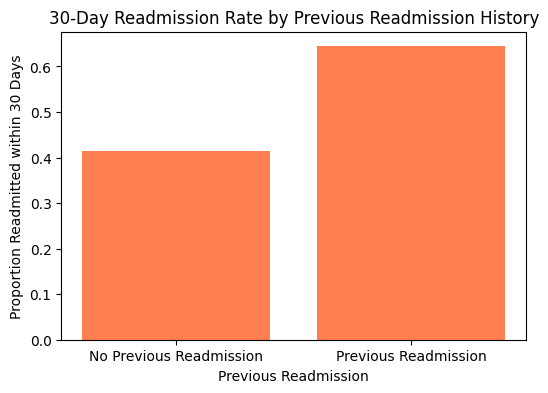

In [17]:
plt.figure(figsize=(6, 4))
plt.bar(
    ["No Previous Readmission", "Previous Readmission"],
    readmit_rate_by_prev.values,
    color="coral"
)
plt.title("30-Day Readmission Rate by Previous Readmission History")
plt.xlabel("Previous Readmission")
plt.ylabel("Proportion Readmitted within 30 Days")
plt.show()


In [18]:
# Compare average number of prior visits for readmitted vs. non-readmitted patients
prior_visits_avg = df.groupby("readmitted_30_days")["num_prior_visits"].mean()
prior_visits_avg


readmitted_30_days
0    1.908024
1    2.078668
Name: num_prior_visits, dtype: float64

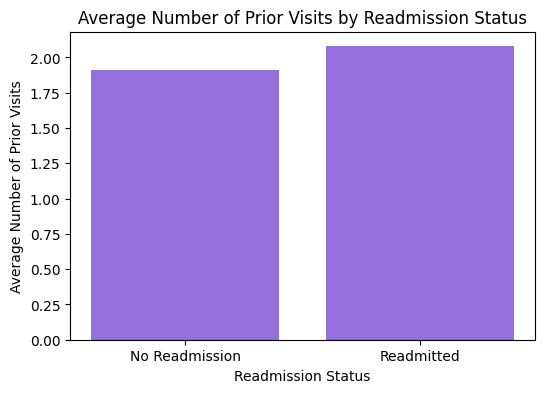

In [19]:
plt.figure(figsize=(6, 4))
plt.bar(
    ["No Readmission", "Readmitted"],
    prior_visits_avg.values,
    color="mediumpurple"
)
plt.title("Average Number of Prior Visits by Readmission Status")
plt.xlabel("Readmission Status")
plt.ylabel("Average Number of Prior Visits")
plt.show()


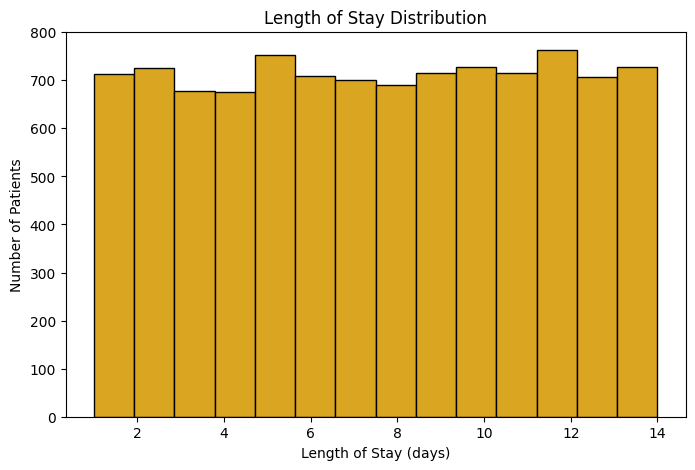

In [20]:
plt.figure(figsize=(8, 5))
plt.hist(df["length_of_stay"], bins=14, color="goldenrod", edgecolor="black")
plt.title("Length of Stay Distribution")
plt.xlabel("Length of Stay (days)")
plt.ylabel("Number of Patients")
plt.show()


 Prepare Features and Target



In [21]:
X = df.drop("readmitted_30_days", axis=1)
y = df["readmitted_30_days"]

X = pd.get_dummies(X, columns=["gender"], drop_first=True)

X.head()


,age,heart_rate,systolic_bp,diastolic_bp,temperature,oxygen_saturation,num_prior_visits,num_emergency_visits,num_inpatient_visits,num_diagnoses,length_of_stay,diabetes,hypertension,previous_readmission,gender_Male
0,69,68.0,101.0,73.0,98.7,96.2,0,1,1,1,13,0,0,1,True
1,32,86.0,120.0,81.0,98.6,96.6,3,1,0,8,4,1,1,1,True
2,89,76.0,139.0,95.0,97.9,92.3,4,0,2,9,7,0,1,0,True
3,78,73.0,150.0,80.0,99.7,100.4,5,3,2,3,5,1,0,0,True
4,38,68.0,120.0,67.0,97.8,97.2,3,0,2,7,1,0,0,0,False


In [22]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("X_train shape:", X_train.shape)
print("X_test shape :", X_test.shape)
print("y_train shape:", y_train.shape)
print("y_test shape :", y_test.shape)


X_train shape: (8000, 15)
X_test shape : (2000, 15)
y_train shape: (8000,)
y_test shape : (2000,)


    Feature Scaling

In [23]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)


In [24]:
model = LogisticRegression(
    penalty="l2",
    C=1.0
)

model.fit(X_train_scaled, y_train)


c:\Users\moham\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\linear_model\_logistic.py:1403: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', l1_ratio set to a float between 0 and 1 instead of penalty='elasticnet', and C=np.inf instead of penalty=None.
  warnings.warn(


,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add an L2 penalty term and it is the default choice;- `'l1'`: add an L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` and `C` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'`, `l1_ratio` set to any float between 0 and 1 for `penalty='elasticnet'`, and `C=np.inf` for `penalty=None`.",'l2'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation <regularized-logistic-loss>`) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary <random_state>` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver beca

In [27]:
y_pred = model.predict(X_test_scaled)
y_prob = model.predict_proba(X_test_scaled)[:, 1]
y_prob[:10]


array([0.57162462, 0.19600204, 0.33769792, 0.71529403, 0.3415249 ,
       0.51638101, 0.57399446, 0.50321066, 0.21666754, 0.15440109])

## 11. Model Evaluation

In [28]:
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
roc_auc = roc_auc_score(y_test, y_prob)

print("Accuracy :", accuracy)
print("Precision:", precision)
print("Recall   :", recall)
print("F1 Score :", f1)
print("ROC-AUC  :", roc_auc)


Accuracy : 0.6605
Precision: 0.6552941176470588
Recall   : 0.5906680805938495
F1 Score : 0.6213050752928053
ROC-AUC  : 0.7163403899268723


In [29]:
print(classification_report(y_test, y_pred))


              precision    recall  f1-score   support

           0       0.66      0.72      0.69      1057
           1       0.66      0.59      0.62       943

    accuracy                           0.66      2000
   macro avg       0.66      0.66      0.66      2000
weighted avg       0.66      0.66      0.66      2000



In [30]:
cm = confusion_matrix(y_test, y_pred)
cm


array([[764, 293],
       [386, 557]])

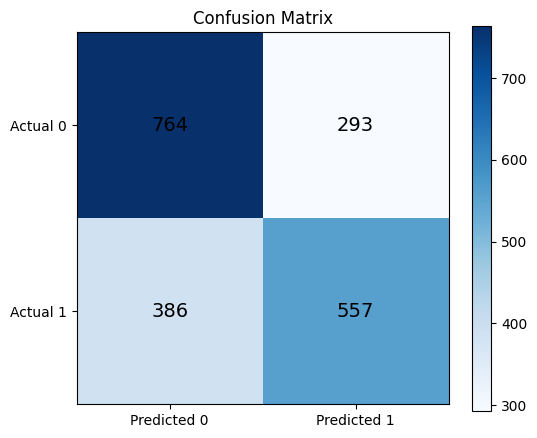

In [31]:
fig, ax = plt.subplots(figsize=(6, 5))
im = ax.imshow(cm, cmap="Blues")

ax.set_xticks([0, 1])
ax.set_xticklabels(["Predicted 0", "Predicted 1"])
ax.set_yticks([0, 1])
ax.set_yticklabels(["Actual 0", "Actual 1"])

# Add the count values inside each cell
for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        ax.text(j, i, cm[i, j], ha="center", va="center", color="black", fontsize=14)

ax.set_title("Confusion Matrix")
plt.colorbar(im)
plt.show()


## 13. ROC Curve

The ROC (Receiver Operating Characteristic) curve shows the trade-off between the **True Positive Rate** (recall) and the **False Positive Rate** as the classification threshold changes. A curve that bows further toward the top-left corner indicates better separation between the two classes. The dashed diagonal line represents random guessing.


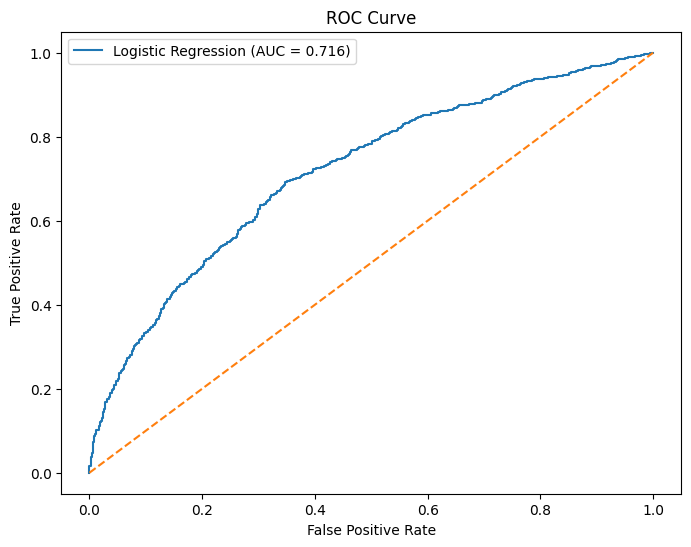

In [32]:
fpr, tpr, thresholds = roc_curve(y_test, y_prob)

plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, label=f"Logistic Regression (AUC = {roc_auc:.3f})")
plt.plot([0, 1], [0, 1], linestyle="--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.show()


As reported above, the model achieved an **ROC-AUC of the value calculated earlier** on the test set, which reflects how well it separates the two classes across all thresholds, not just the default 0.5 cutoff.


In [33]:
coefficients = pd.DataFrame({
    "Feature": X.columns,
    "Coefficient": model.coef_[0]
})

coefficients = coefficients.sort_values(by="Coefficient", ascending=False)
coefficients


,Feature,Coefficient
13,previous_readmission,0.447359
0,age,0.312585
9,num_diagnoses,0.277168
1,heart_rate,0.204449
10,length_of_stay,0.195394
8,num_inpatient_visits,0.191427
11,diabetes,0.182038
2,systolic_bp,0.174408
12,hypertension,0.170058
7,num_emergency_visits,0.139130


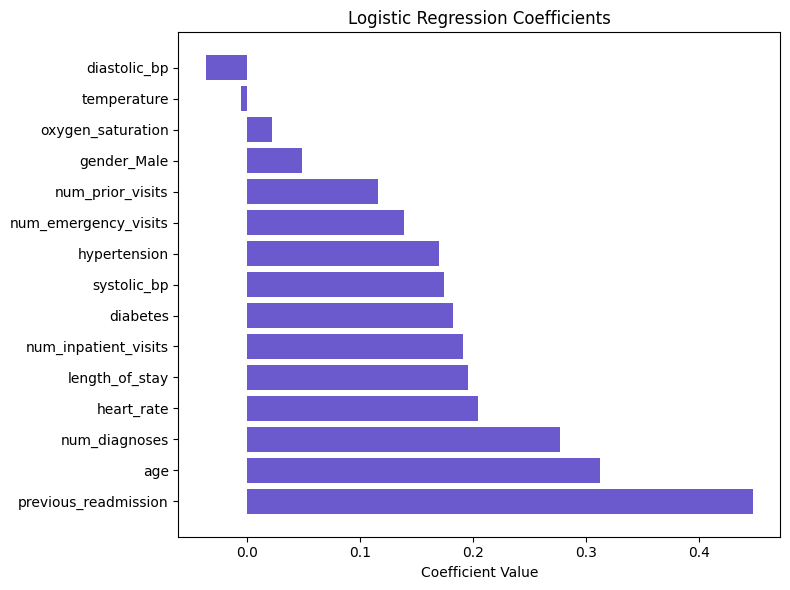

In [34]:
plt.figure(figsize=(8, 6))
plt.barh(coefficients["Feature"], coefficients["Coefficient"], color="slateblue")
plt.title("Logistic Regression Coefficients")
plt.xlabel("Coefficient Value")
plt.tight_layout()
plt.show()


In [ ]:
# Build a small DataFrame with the actual values, predicted classes, and predicted probabilities
predictions_df = pd.DataFrame({
    "Actual": y_test.values,
    "Predicted": y_pred,
    "Predicted_Probability": y_prob
})

predictions_df.insert(0, "Patient_Index", y_test.index)

predictions_df.head()


,Patient_Index,Actual,Predicted,Predicted_Probability
0,2929,0,1,0.571625
1,477,1,0,0.196002
2,5248,0,0,0.337698
3,8956,1,1,0.715294
4,7459,0,0,0.341525


In [37]:
predictions_df.to_csv("hospital_readmission_predictions.csv", index=False)

print("Predictions saved successfully!")


Predictions saved successfully!


In [38]:
# Load the saved file back in to confirm it was written correctly
check_predictions_df = pd.read_csv("hospital_readmission_predictions.csv")

print(check_predictions_df.shape)
check_predictions_df.head()


(2000, 4)


,Patient_Index,Actual,Predicted,Predicted_Probability
0,2929,0,1,0.571625
1,477,1,0,0.196002
2,5248,0,0,0.337698
3,8956,1,1,0.715294
4,7459,0,0,0.341525
